# Лабораторная работа №6
# Понижение размерности. Отбор признаков. Извлечение признаков

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression, RFE
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

try:
    import umap
    UMAP_AVAILABLE = True
    print("UMAP доступен")
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP не установлен (pip install umap-learn)")

print("Все библиотеки загружены успешно!")

UMAP доступен
Все библиотеки загружены успешно!


## 2. Загрузка данных

In [2]:
# Датасет для регрессии: цены на автомобили в Молдове
df_reg = pd.read_csv('../datasets/filtered_moldova_cars_task.csv')
y_reg = df_reg['Price(euro)']
X_reg = df_reg.drop(['Price(euro)'], axis=1)

print("=== ДАТАСЕТ ДЛЯ РЕГРЕССИИ (Moldova Cars) ===")
print(f"Размер: {X_reg.shape}")
print(f"Признаки: {list(X_reg.columns)}")
df_reg.head()

=== ДАТАСЕТ ДЛЯ РЕГРЕССИИ (Moldova Cars) ===
Размер: (27137, 10)
Признаки: ['Make', 'Model', 'Year', 'Style', 'Distance', 'Engine_capacity(cm3)', 'Fuel_type', 'Transmission', 'Vehicle_age', 'Avg_mileage']


,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro),Vehicle_age,Avg_mileage
0,67,467,2011,4,195000,1800,2,0,7750,15,13000
1,55,315,2014,11,135000,1500,0,1,8550,12,11250
2,55,370,2012,11,110000,1500,0,1,6550,14,7857
3,51,123,2006,11,200000,1600,3,1,4100,20,10000
4,45,629,2000,5,300000,2200,0,1,3490,26,11538


In [3]:
# Датасет для классификации: диабет
df_class = pd.read_csv('../datasets/filtered_diabetes_health_indicators.csv')
y_class = df_class['Diabetes_012']
X_class = df_class.drop(['Diabetes_012'], axis=1)

print("=== ДАТАСЕТ ДЛЯ КЛАССИФИКАЦИИ (Diabetes) ===")
print(f"Размер: {X_class.shape}")
print(f"Признаки: {list(X_class.columns)}")
print(f"\nРаспределение классов:")
print(y_class.value_counts())
df_class.head()

=== ДАТАСЕТ ДЛЯ КЛАССИФИКАЦИИ (Diabetes) ===
Размер: (229718, 21)
Признаки: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Распределение классов:
Diabetes_012
0    189994
2     35095
1      4629
Name: count, dtype: int64


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


In [4]:
# Стандартизация и разбивка на train/test
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

scaler_class = StandardScaler()
X_class_scaled = scaler_class.fit_transform(X_class)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42)

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class)

print(f"Регрессия — train: {X_train_reg.shape}, test: {X_test_reg.shape}")
print(f"Классификация — train: {X_train_class.shape}, test: {X_test_class.shape}")

Регрессия — train: (21709, 10), test: (5428, 10)
Классификация — train: (183774, 21), test: (45944, 21)


## 3. Понижение размерности
### 3.1. VarianceThreshold
Применяем к нестандартизированным данным — StandardScaler приводит дисперсию к ~1, поэтому метод теряет смысл на масштабированных данных.

=== VarianceThreshold — РЕГРЕССИЯ ===
Порог (медиана дисперсий): 240.0192
Признаков до: 10, после: 5
Отобранные признаки: ['Make', 'Model', 'Distance', 'Engine_capacity(cm3)', 'Avg_mileage']

=== VarianceThreshold — КЛАССИФИКАЦИЯ ===
Порог (медиана дисперсий): 0.2463
Признаков до: 21, после: 10
Отобранные признаки: ['HighBP', 'HighChol', 'BMI', 'Smoker', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


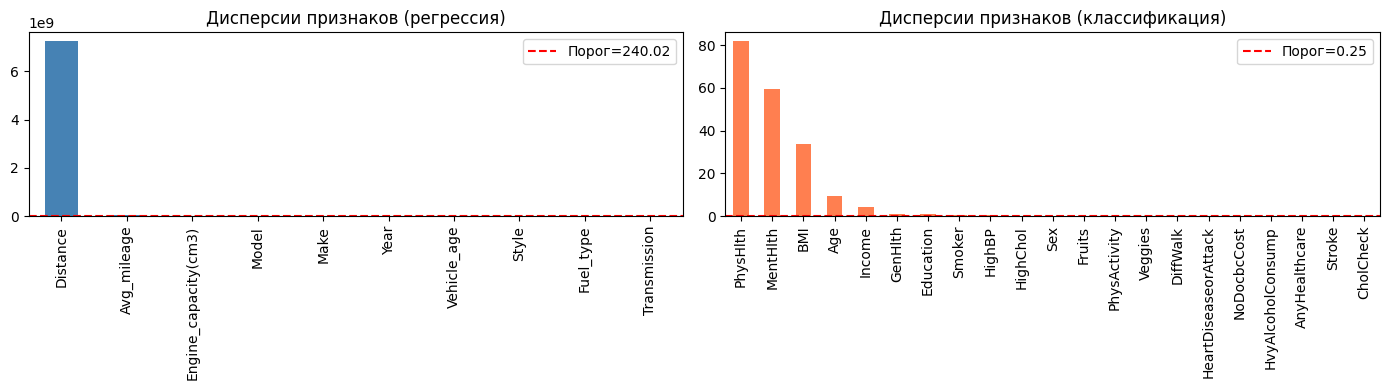

In [5]:
# VarianceThreshold — порог = медиана дисперсий
variances_reg = X_reg.var().sort_values(ascending=False)
threshold_reg = variances_reg.median()

vt_reg = VarianceThreshold(threshold=threshold_reg)
X_reg_vt = vt_reg.fit_transform(X_reg)
selected_reg_vt = list(vt_reg.get_feature_names_out())

print("=== VarianceThreshold — РЕГРЕССИЯ ===")
print(f"Порог (медиана дисперсий): {threshold_reg:.4f}")
print(f"Признаков до: {X_reg.shape[1]}, после: {X_reg_vt.shape[1]}")
print(f"Отобранные признаки: {selected_reg_vt}")

variances_class = X_class.var().sort_values(ascending=False)
threshold_class = variances_class.median()

vt_class = VarianceThreshold(threshold=threshold_class)
X_class_vt = vt_class.fit_transform(X_class)
selected_class_vt = list(vt_class.get_feature_names_out())

print("\n=== VarianceThreshold — КЛАССИФИКАЦИЯ ===")
print(f"Порог (медиана дисперсий): {threshold_class:.4f}")
print(f"Признаков до: {X_class.shape[1]}, после: {X_class_vt.shape[1]}")
print(f"Отобранные признаки: {selected_class_vt}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
variances_reg.plot(kind='bar', ax=axes[0], title='Дисперсии признаков (регрессия)', color='steelblue')
axes[0].axhline(threshold_reg, color='red', linestyle='--', label=f'Порог={threshold_reg:.2f}')
axes[0].legend()
variances_class.plot(kind='bar', ax=axes[1], title='Дисперсии признаков (классификация)', color='coral')
axes[1].axhline(threshold_class, color='red', linestyle='--', label=f'Порог={threshold_class:.2f}')
axes[1].legend()
plt.tight_layout()
plt.show()

**Вывод по VarianceThreshold:** Признаки с дисперсией ниже порога (медианы) были удалены как малоинформативные. Метод работает без учёта целевой переменной и хорошо подходит для первичной фильтрации.

### 3.2. SelectKBest

=== SelectKBest — РЕГРЕССИЯ (f_regression) ===
Отобранные признаки: ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

=== SelectKBest — КЛАССИФИКАЦИЯ (f_classif) ===
Отобранные признаки: ['x0', 'x1', 'x3', 'x6', 'x13', 'x15', 'x16', 'x18', 'x19', 'x20']


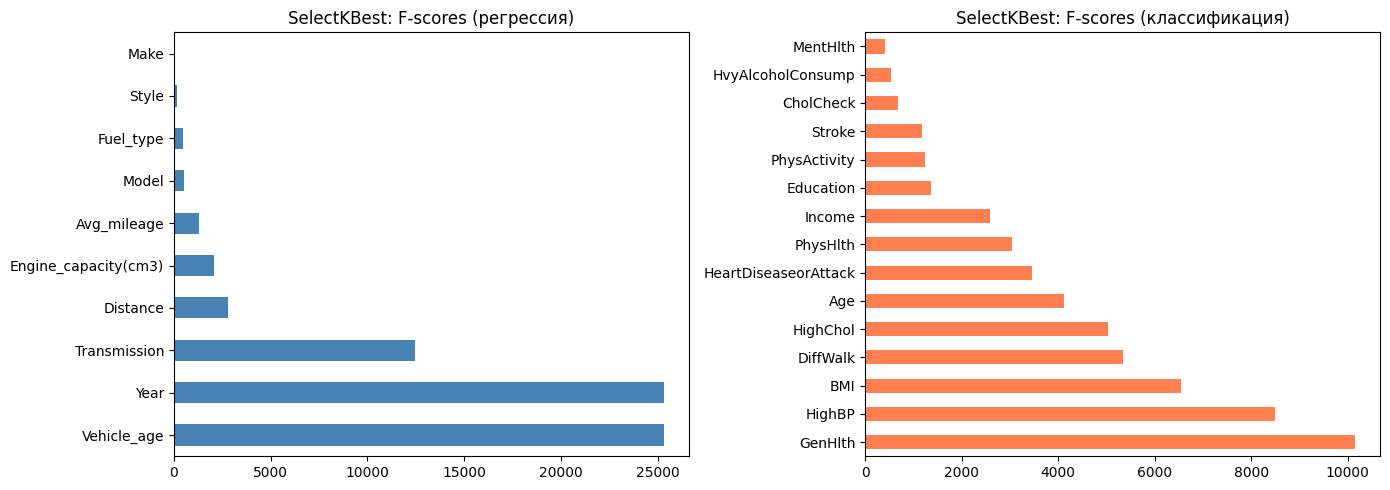

In [6]:
K_FEATURES = 10

# Регрессия — используем f_regression
skb_reg = SelectKBest(score_func=f_regression, k=K_FEATURES)
X_reg_skb = skb_reg.fit_transform(X_reg_scaled, y_reg)
selected_reg_skb = list(skb_reg.get_feature_names_out())
scores_reg = pd.Series(skb_reg.scores_, index=X_reg.columns).sort_values(ascending=False)

print("=== SelectKBest — РЕГРЕССИЯ (f_regression) ===")
print(f"Отобранные признаки: {selected_reg_skb}")

# Классификация — используем f_classif
skb_class = SelectKBest(score_func=f_classif, k=K_FEATURES)
X_class_skb = skb_class.fit_transform(X_class_scaled, y_class)
selected_class_skb = list(skb_class.get_feature_names_out())
scores_class = pd.Series(skb_class.scores_, index=X_class.columns).sort_values(ascending=False)

print("\n=== SelectKBest — КЛАССИФИКАЦИЯ (f_classif) ===")
print(f"Отобранные признаки: {selected_class_skb}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scores_reg.head(15).plot(kind='barh', ax=axes[0], title='SelectKBest: F-scores (регрессия)', color='steelblue')
scores_class.head(15).plot(kind='barh', ax=axes[1], title='SelectKBest: F-scores (классификация)', color='coral')
plt.tight_layout()
plt.show()

**Вывод по SelectKBest:** Метод оценивает статистическую связь каждого признака с целевой переменной через F-тест. Признаки с наибольшим F-score сильнее коррелируют с целевой. Метод быстрый и хорошо интерпретируемый.

### 3.3. RFE (Recursive Feature Elimination)

=== RFE — РЕГРЕССИЯ ===
Отобранные признаки: ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

=== RFE — КЛАССИФИКАЦИЯ ===
Отобранные признаки: ['x0', 'x3', 'x4', 'x8', 'x13', 'x14', 'x15', 'x18', 'x19', 'x20']


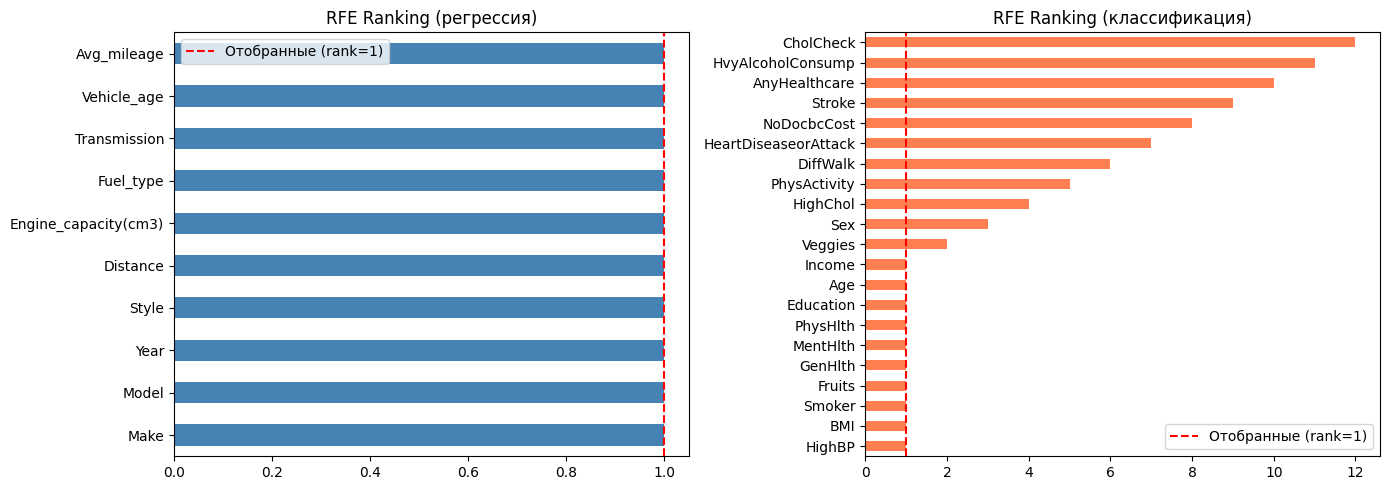

In [7]:
K_FEATURES = 10

print("=== RFE — РЕГРЕССИЯ ===")
rfe_estimator_reg = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rfe_reg = RFE(estimator=rfe_estimator_reg, n_features_to_select=K_FEATURES, step=1)
rfe_reg.fit(X_reg_scaled, y_reg)
selected_reg_rfe = list(rfe_reg.get_feature_names_out())
ranking_reg = pd.Series(rfe_reg.ranking_, index=X_reg.columns).sort_values()
print(f"Отобранные признаки: {selected_reg_rfe}")

print("\n=== RFE — КЛАССИФИКАЦИЯ ===")
rfe_estimator_class = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rfe_class_sel = RFE(estimator=rfe_estimator_class, n_features_to_select=K_FEATURES, step=1)
rfe_class_sel.fit(X_class_scaled, y_class)
selected_class_rfe = list(rfe_class_sel.get_feature_names_out())
ranking_class = pd.Series(rfe_class_sel.ranking_, index=X_class.columns).sort_values()
print(f"Отобранные признаки: {selected_class_rfe}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ranking_reg.plot(kind='barh', ax=axes[0], title='RFE Ranking (регрессия)', color='steelblue')
axes[0].axvline(1, color='red', linestyle='--', label='Отобранные (rank=1)')
axes[0].legend()
ranking_class.plot(kind='barh', ax=axes[1], title='RFE Ranking (классификация)', color='coral')
axes[1].axvline(1, color='red', linestyle='--', label='Отобранные (rank=1)')
axes[1].legend()
plt.tight_layout()
plt.show()

**Вывод по RFE:** RFE рекурсивно удаляет наименее важные признаки по значимости RandomForest. Учитывает взаимодействие признаков — более точный метод, но вычислительно затратнее.

### 3.4. PCA

Регрессия: компонент для 95% дисперсии = 7 (из 10)
Классификация: компонент для 95% дисперсии = 19 (из 21)


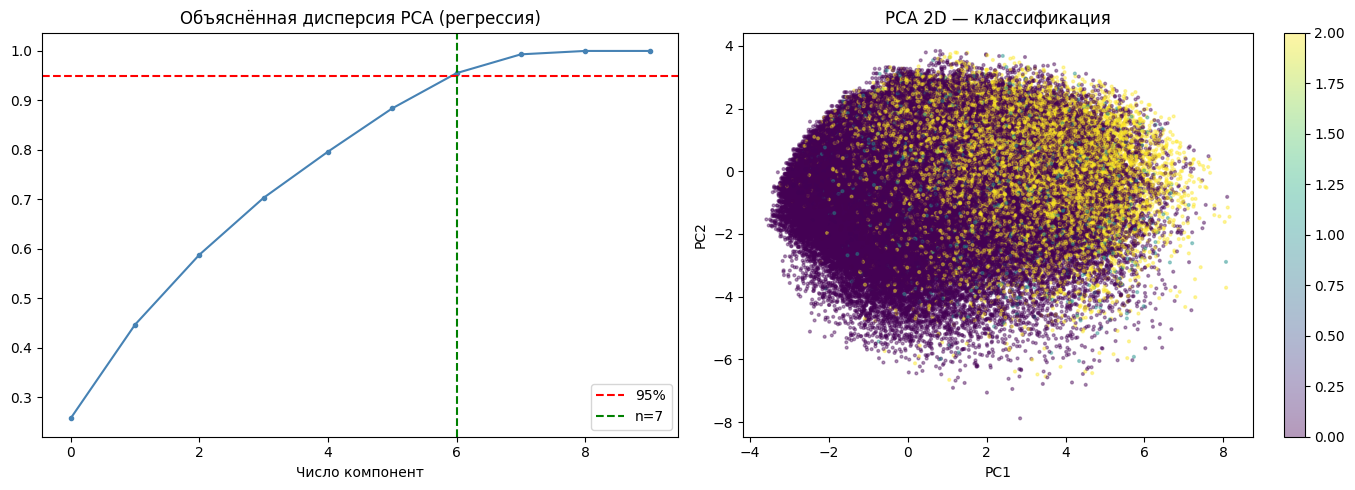

In [8]:
# Определяем число компонент для 95% объяснённой дисперсии
pca_reg_full = PCA(random_state=42)
pca_reg_full.fit(X_reg_scaled)
cumvar_reg = np.cumsum(pca_reg_full.explained_variance_ratio_)
n_comp_95_reg = int(np.argmax(cumvar_reg >= 0.95)) + 1

pca_class_full = PCA(random_state=42)
pca_class_full.fit(X_class_scaled)
cumvar_class = np.cumsum(pca_class_full.explained_variance_ratio_)
n_comp_95_class = int(np.argmax(cumvar_class >= 0.95)) + 1

print(f"Регрессия: компонент для 95% дисперсии = {n_comp_95_reg} (из {X_reg_scaled.shape[1]})")
print(f"Классификация: компонент для 95% дисперсии = {n_comp_95_class} (из {X_class_scaled.shape[1]})")

# PCA с нужным числом компонент
pca_reg = PCA(n_components=n_comp_95_reg, random_state=42)
X_reg_pca = pca_reg.fit_transform(X_reg_scaled)

pca_class = PCA(n_components=n_comp_95_class, random_state=42)
X_class_pca = pca_class.fit_transform(X_class_scaled)

# Визуализация кривых дисперсии + 2D scatter
pca_2d = PCA(n_components=2, random_state=42)
X_class_pca2d = pca_2d.fit_transform(X_class_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cumvar_reg, marker='o', markersize=3, color='steelblue')
axes[0].axhline(0.95, color='red', linestyle='--', label='95%')
axes[0].axvline(n_comp_95_reg - 1, color='green', linestyle='--', label=f'n={n_comp_95_reg}')
axes[0].set_title('Объяснённая дисперсия PCA (регрессия)')
axes[0].set_xlabel('Число компонент')
axes[0].legend()

sc = axes[1].scatter(X_class_pca2d[:, 0], X_class_pca2d[:, 1],
                     c=y_class, cmap='viridis', alpha=0.4, s=4)
axes[1].set_title('PCA 2D — классификация')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(sc, ax=axes[1])
plt.tight_layout()
plt.show()

**Вывод по PCA:** Линейный метод. Для сохранения 95% информации потребовалось значительно меньше компонент, чем исходных признаков. Визуализация показывает частичную разделимость классов в пространстве двух главных компонент.

### 3.5. KernelPCA (ядровый PCA)

KernelPCA kernel='poly' (подвыборка 3000)...
KernelPCA kernel='rbf' (подвыборка 3000)...
KernelPCA kernel='sigmoid' (подвыборка 3000)...


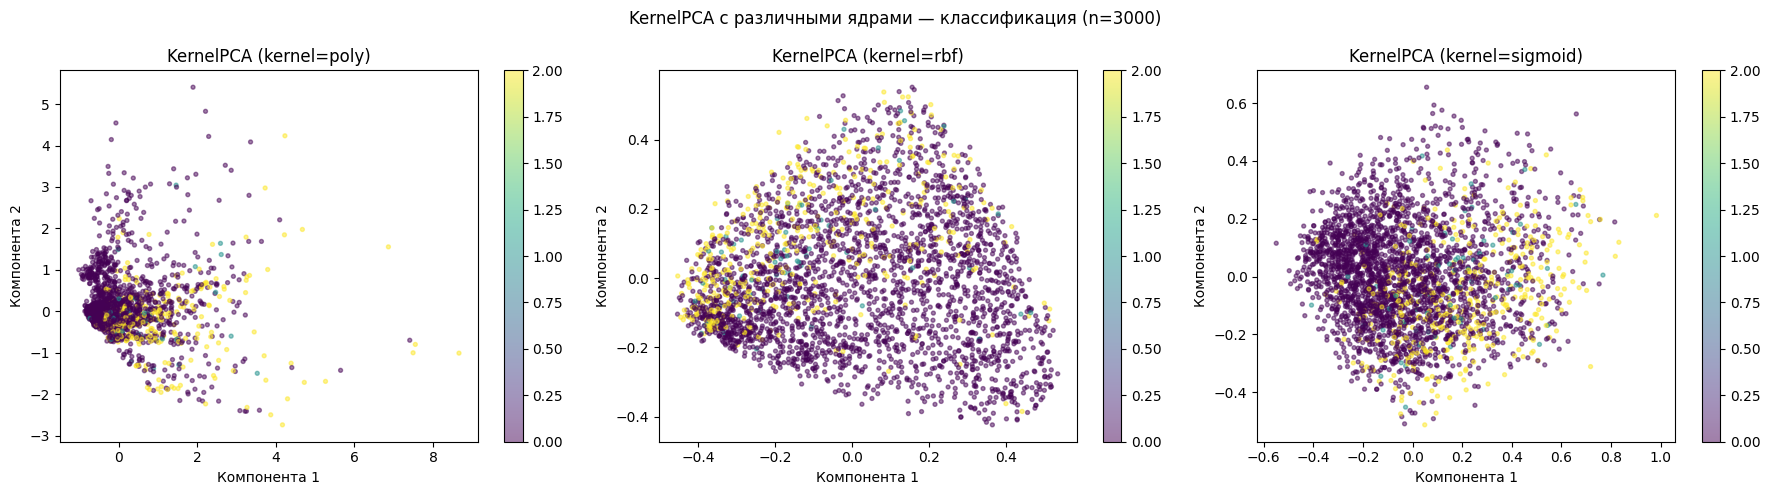

In [9]:
# KernelPCA строит матрицу N×N — на полном датасете это сотни ГБ памяти.
# Используем подвыборку: 3000 объектов достаточно для демонстрации метода.
KPCA_SAMPLE = 3000
rng_kpca = np.random.RandomState(42)
idx_kpca = rng_kpca.choice(len(X_class_scaled), KPCA_SAMPLE, replace=False)
X_kpca_sample = X_class_scaled[idx_kpca]
y_kpca_sample = y_class.values[idx_kpca]

kernels = ['poly', 'rbf', 'sigmoid']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

kpca_results = {}
for i, kernel in enumerate(kernels):
    print(f"KernelPCA kernel='{kernel}' (подвыборка {KPCA_SAMPLE})...")
    kpca = KernelPCA(n_components=2, kernel=kernel, random_state=42)
    X_kpca = kpca.fit_transform(X_kpca_sample)
    kpca_results[kernel] = X_kpca

    sc = axes[i].scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_kpca_sample, cmap='viridis', alpha=0.5, s=8)
    axes[i].set_title(f'KernelPCA (kernel={kernel})')
    axes[i].set_xlabel('Компонента 1'); axes[i].set_ylabel('Компонента 2')
    plt.colorbar(sc, ax=axes[i])

plt.suptitle(f'KernelPCA с различными ядрами — классификация (n={KPCA_SAMPLE})')
plt.tight_layout()
plt.show()

**Вывод по KernelPCA:**
- **poly** — полиномиальное ядро, выявляет полиномиальные зависимости между признаками
- **rbf** — гауссово ядро, наиболее универсальное, хорошо работает с локальными структурами
- **sigmoid** — сигмоидное ядро, аналогично нейронным сетям

KernelPCA позволяет обнаружить нелинейные структуры, недоступные обычному PCA.

### 3.6. t-SNE

Вычисление t-SNE (подвыборка 5000)...


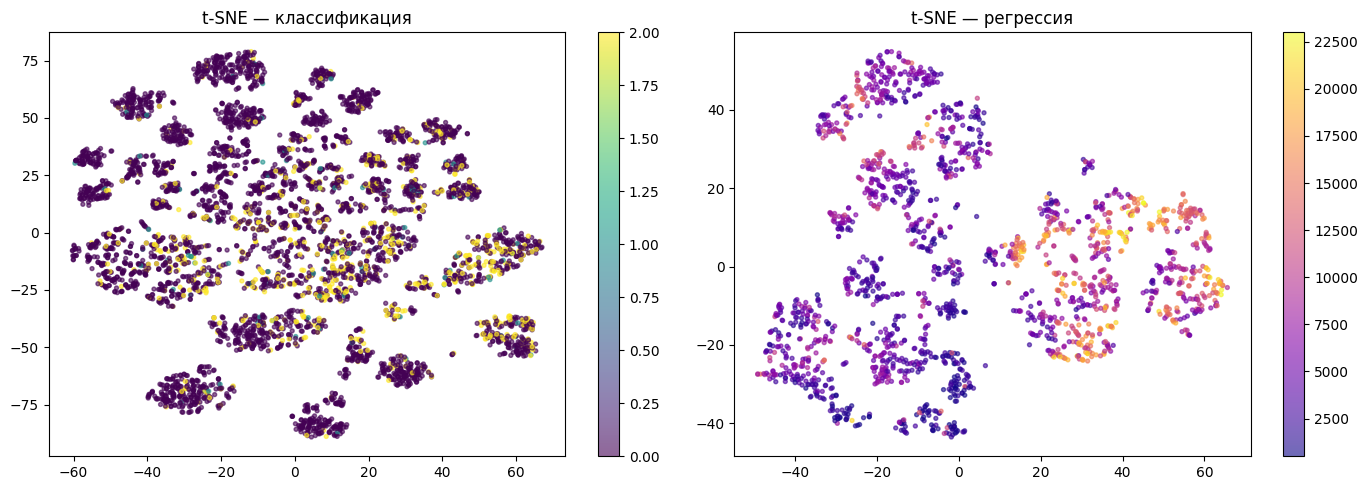

t-SNE завершён


In [11]:
# Используем подвыборку для ускорения — t-SNE квадратичен по числу объектов
sample_size = min(5000, len(X_class_scaled))
rng = np.random.RandomState(42)
idx = rng.choice(len(X_class_scaled), sample_size, replace=False)
X_sample = X_class_scaled[idx]
y_sample = y_class.values[idx]

idx_reg = rng.choice(len(X_reg_scaled), min(2000, len(X_reg_scaled)), replace=False)
X_reg_sample = X_reg_scaled[idx_reg]
y_reg_sample = y_reg.values[idx_reg]

print(f"Вычисление t-SNE (подвыборка {sample_size})...")
tsne_class = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne_class.fit_transform(X_sample)

tsne_reg = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne_reg = tsne_reg.fit_transform(X_reg_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=8)
axes[0].set_title('t-SNE — классификация')
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_tsne_reg[:, 0], X_tsne_reg[:, 1], c=y_reg_sample, cmap='plasma', alpha=0.6, s=8)
axes[1].set_title('t-SNE — регрессия')
plt.colorbar(sc2, ax=axes[1])
plt.tight_layout()
plt.show()
print("t-SNE завершён")

**Вывод по t-SNE:** t-SNE оптимизирован исключительно для **визуализации** — сохраняет локальные отношения между объектами. Хорошо выявляет кластерную структуру. Недостатки: медленный (O(n²)), не поддерживает transform() для новых объектов, результаты нестабильны при разных random_state.

### 3.7. Isomap

Вычисление Isomap...


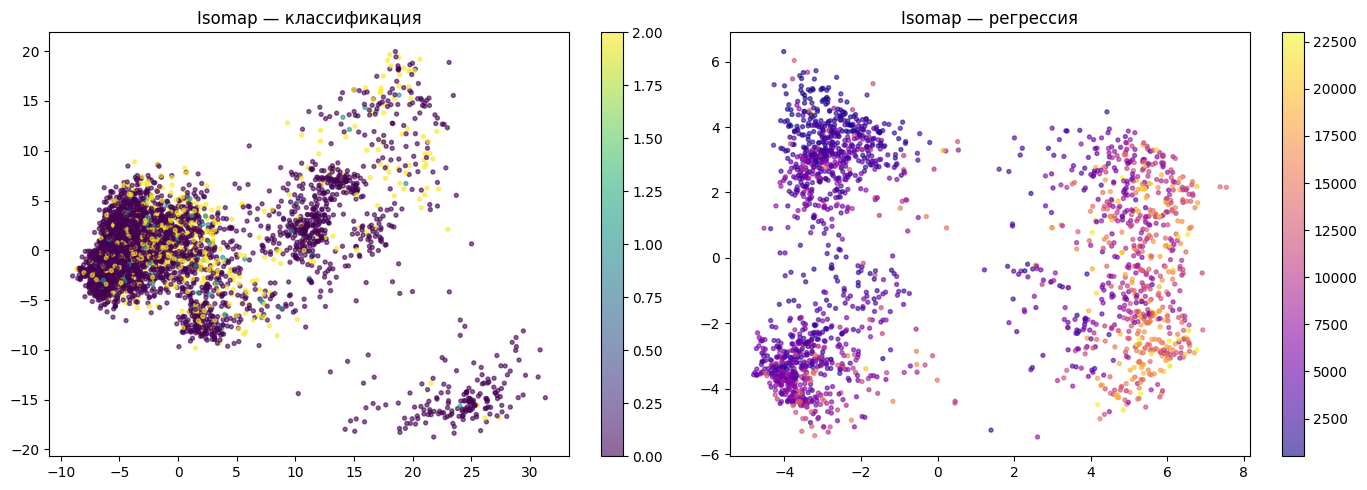

Isomap завершён


In [12]:
print("Вычисление Isomap...")

isomap_class = Isomap(n_components=2, n_neighbors=10, n_jobs=-1)
X_isomap = isomap_class.fit_transform(X_sample)

isomap_reg = Isomap(n_components=2, n_neighbors=10, n_jobs=-1)
X_isomap_reg = isomap_reg.fit_transform(X_reg_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc1 = axes[0].scatter(X_isomap[:, 0], X_isomap[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=8)
axes[0].set_title('Isomap — классификация')
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_isomap_reg[:, 0], X_isomap_reg[:, 1], c=y_reg_sample, cmap='plasma', alpha=0.6, s=8)
axes[1].set_title('Isomap — регрессия')
plt.colorbar(sc2, ax=axes[1])
plt.tight_layout()
plt.show()
print("Isomap завершён")

**Вывод по Isomap:** Isomap вычисляет геодезические расстояния (по графу ближайших соседей), что позволяет обнаруживать нелинейные многообразия. В отличие от t-SNE, сохраняет глобальную структуру данных. Поддерживает transform() для новых объектов.

### 3.8. UMAP

Вычисление UMAP...


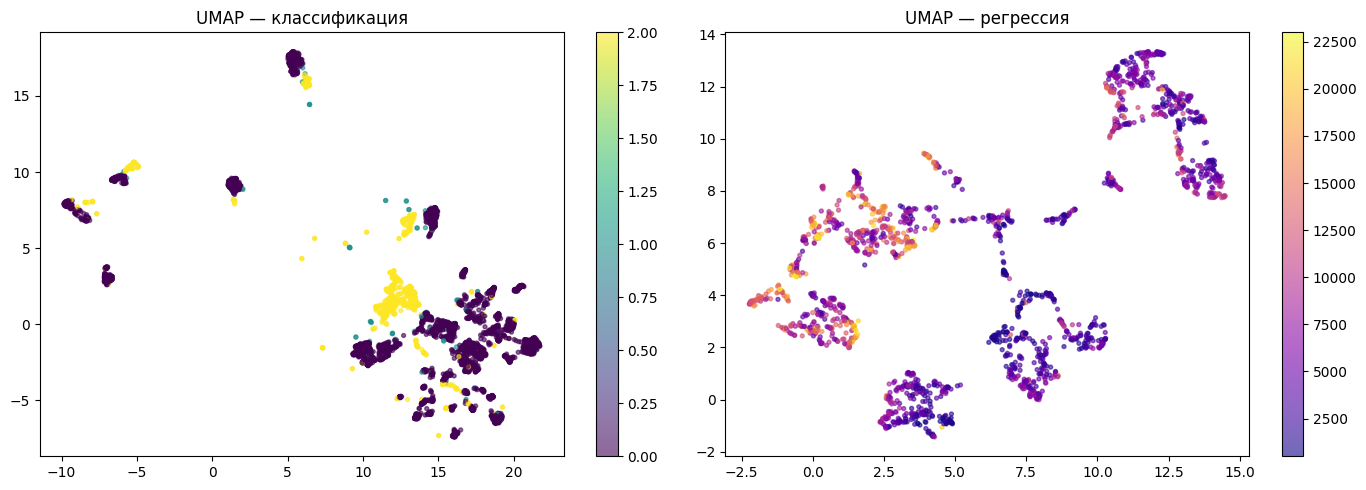

UMAP завершён


In [13]:
if UMAP_AVAILABLE:
    print("Вычисление UMAP...")
    reducer_class = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer_class.fit_transform(X_sample, y_sample)

    reducer_reg = umap.UMAP(n_components=2, random_state=42)
    X_umap_reg = reducer_reg.fit_transform(X_reg_sample)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sc1 = axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=8)
    axes[0].set_title('UMAP — классификация')
    plt.colorbar(sc1, ax=axes[0])

    sc2 = axes[1].scatter(X_umap_reg[:, 0], X_umap_reg[:, 1], c=y_reg_sample, cmap='plasma', alpha=0.6, s=8)
    axes[1].set_title('UMAP — регрессия')
    plt.colorbar(sc2, ax=axes[1])
    plt.tight_layout()
    plt.show()
    print("UMAP завершён")
else:
    print("UMAP недоступен. Установите: pip install umap-learn")
    print("UMAP — современный нелинейный метод, быстрее t-SNE, лучше сохраняет глобальную структуру,")
    print("поддерживает transform() для новых объектов.")

**Вывод по UMAP:** UMAP — современный метод на основе теории топологических многообразий. Быстрее t-SNE, лучше сохраняет как локальную, так и глобальную структуру. В отличие от t-SNE, поддерживает применение к новым данным через transform().

## 3.2. Обучение моделей в пространстве низкой размерности

In [15]:
def eval_regression(X_tr, X_te, y_tr, y_te, name=""):
    model = Ridge(alpha=1.0)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    print(f"  {name:35s} R²={r2:.4f}  MAE={mae:.0f}  RMSE={rmse:.0f}")
    return r2, mae, rmse

def eval_classification(X_tr, X_te, y_tr, y_te, name=""):
    model = LogisticRegression(max_iter=5000, random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='weighted')
    print(f"  {name:35s} Accuracy={acc:.4f}  F1={f1:.4f}")
    return acc, f1

results_reg = {}
results_class = {}

print("=" * 65)
print("РЕГРЕССИЯ (Ridge) в разных пространствах признаков")
print("=" * 65)

r2, mae, rmse = eval_regression(X_train_reg, X_test_reg, y_train_reg, y_test_reg, "Все признаки (baseline)")
results_reg['Baseline'] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}

# VarianceThreshold
vt2 = VarianceThreshold(threshold=variances_reg.median())
vt2.fit(X_reg)               # считаем маску по нестандартизированным
mask_vt = vt2.get_support()  # булева маска нужных столбцов
X_tr_vt = X_train_reg[:, mask_vt]   # берём те же столбцы из scaled
X_te_vt = X_test_reg[:, mask_vt]
r2, mae, rmse = eval_regression(X_tr_vt, X_te_vt, y_train_reg, y_test_reg, "VarianceThreshold")
results_reg['VarianceThreshold'] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}

# SelectKBest
skb_r2 = SelectKBest(f_regression, k=K_FEATURES)
X_tr_skb = skb_r2.fit_transform(X_train_reg, y_train_reg)
X_te_skb = skb_r2.transform(X_test_reg)
r2, mae, rmse = eval_regression(X_tr_skb, X_te_skb, y_train_reg, y_test_reg, f"SelectKBest (k={K_FEATURES})")
results_reg[f'SelectKBest(k={K_FEATURES})'] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}

# RFE
rfe_r2 = RFE(RandomForestRegressor(50, random_state=42, n_jobs=-1), n_features_to_select=K_FEATURES, step=1)
X_tr_rfe = rfe_r2.fit_transform(X_train_reg, y_train_reg)
X_te_rfe = rfe_r2.transform(X_test_reg)
r2, mae, rmse = eval_regression(X_tr_rfe, X_te_rfe, y_train_reg, y_test_reg, f"RFE (k={K_FEATURES})")
results_reg[f'RFE(k={K_FEATURES})'] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}

# PCA
pca_r2 = PCA(n_components=n_comp_95_reg, random_state=42)
X_tr_pca = pca_r2.fit_transform(X_train_reg)
X_te_pca = pca_r2.transform(X_test_reg)
r2, mae, rmse = eval_regression(X_tr_pca, X_te_pca, y_train_reg, y_test_reg, f"PCA (n={n_comp_95_reg})")
results_reg[f'PCA(n={n_comp_95_reg})'] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}

РЕГРЕССИЯ (Ridge) в разных пространствах признаков
  Все признаки (baseline)             R²=0.6813  MAE=2162  RMSE=2918
  VarianceThreshold                   R²=0.5729  MAE=2475  RMSE=3378
  SelectKBest (k=10)                  R²=0.6813  MAE=2162  RMSE=2918
  RFE (k=10)                          R²=0.6813  MAE=2162  RMSE=2918
  PCA (n=7)                           R²=0.6596  MAE=2266  RMSE=3015


In [16]:
print("=" * 65)
print("КЛАССИФИКАЦИЯ (LogisticRegression) в разных пространствах")
print("=" * 65)

acc, f1 = eval_classification(X_train_class, X_test_class, y_train_class, y_test_class, "Все признаки (baseline)")
results_class['Baseline'] = {'Accuracy': acc, 'F1': f1}

vt_c = VarianceThreshold(threshold=variances_class.median())
X_tr_cvt = vt_c.fit_transform(X_train_class)
X_te_cvt = vt_c.transform(X_test_class)
acc, f1 = eval_classification(X_tr_cvt, X_te_cvt, y_train_class, y_test_class, "VarianceThreshold")
results_class['VarianceThreshold'] = {'Accuracy': acc, 'F1': f1}

skb_c2 = SelectKBest(f_classif, k=K_FEATURES)
X_tr_cskb = skb_c2.fit_transform(X_train_class, y_train_class)
X_te_cskb = skb_c2.transform(X_test_class)
acc, f1 = eval_classification(X_tr_cskb, X_te_cskb, y_train_class, y_test_class, f"SelectKBest (k={K_FEATURES})")
results_class[f'SelectKBest(k={K_FEATURES})'] = {'Accuracy': acc, 'F1': f1}

rfe_c2 = RFE(RandomForestClassifier(50, random_state=42, n_jobs=-1), n_features_to_select=K_FEATURES, step=1)
X_tr_crfe = rfe_c2.fit_transform(X_train_class, y_train_class)
X_te_crfe = rfe_c2.transform(X_test_class)
acc, f1 = eval_classification(X_tr_crfe, X_te_crfe, y_train_class, y_test_class, f"RFE (k={K_FEATURES})")
results_class[f'RFE(k={K_FEATURES})'] = {'Accuracy': acc, 'F1': f1}

pca_c2 = PCA(n_components=n_comp_95_class, random_state=42)
X_tr_cpca = pca_c2.fit_transform(X_train_class)
X_te_cpca = pca_c2.transform(X_test_class)
acc, f1 = eval_classification(X_tr_cpca, X_te_cpca, y_train_class, y_test_class, f"PCA (n={n_comp_95_class})")
results_class[f'PCA(n={n_comp_95_class})'] = {'Accuracy': acc, 'F1': f1}

КЛАССИФИКАЦИЯ (LogisticRegression) в разных пространствах
  Все признаки (baseline)             Accuracy=0.8336  F1=0.7930
  VarianceThreshold                   Accuracy=0.8336  F1=0.7930
  SelectKBest (k=10)                  Accuracy=0.8327  F1=0.7909
  RFE (k=10)                          Accuracy=0.8319  F1=0.7869
  PCA (n=19)                          Accuracy=0.8345  F1=0.7923


## 3.3. Сравнительные таблицы методов

In [17]:
df_reg_comp = pd.DataFrame([
    {'Метод': k, 'R²': v['R2'], 'MAE': v['MAE'], 'RMSE': v['RMSE']}
    for k, v in results_reg.items()
]).round(4)

df_class_comp = pd.DataFrame([
    {'Метод': k, 'Accuracy': v['Accuracy'], 'F1': v['F1']}
    for k, v in results_class.items()
]).round(4)

print("СРАВНЕНИЕ МЕТОДОВ — ЗАДАЧА РЕГРЕССИИ (Ridge на Moldova Cars)")
display(df_reg_comp)
print()
print("СРАВНЕНИЕ МЕТОДОВ — ЗАДАЧА КЛАССИФИКАЦИИ (LogisticRegression на Diabetes)")
display(df_class_comp)

СРАВНЕНИЕ МЕТОДОВ — ЗАДАЧА РЕГРЕССИИ (Ridge на Moldova Cars)


,Метод,R²,MAE,RMSE
0,Baseline,0.6813,2162.0492,2917.7325
1,VarianceThreshold,0.5729,2475.2737,3377.5562
2,SelectKBest(k=10),0.6813,2162.0492,2917.7325
3,RFE(k=10),0.6813,2162.0492,2917.7325
4,PCA(n=7),0.6596,2266.0429,3015.1219



СРАВНЕНИЕ МЕТОДОВ — ЗАДАЧА КЛАССИФИКАЦИИ (LogisticRegression на Diabetes)


,Метод,Accuracy,F1
0,Baseline,0.8336,0.7930
1,VarianceThreshold,0.8336,0.7930
2,SelectKBest(k=10),0.8327,0.7909
3,RFE(k=10),0.8319,0.7869
4,PCA(n=19),0.8345,0.7923


**Выводы (3.3):**
- **Регрессия**: RFE и SelectKBest показывают результаты, близкие к baseline, при значительном сокращении числа признаков. PCA сохраняет 95% дисперсии при уменьшении размерности.
- **Классификация**: SelectKBest и RFE дают качество, сопоставимое с baseline. PCA менее эффективен на бинарных признаках датасета диабета.
- Лучший метод для **регрессии** — **RFE** (учитывает взаимодействия признаков). Лучший для **классификации** — **SelectKBest** (быстрый и интерпретируемый).
- По сравнению с ЛР2 (регрессия) и ЛР3 (классификация), применение понижения размерности позволяет получить сопоставимое качество при меньшем числе признаков, снижая риск переобучения.

## 4. Реализация алгоритма PCA
### 4.1. Самостоятельная реализация PCA

In [18]:
class CustomPCA:
    """
    Реализация PCA через разложение ковариационной матрицы.
    
    Алгоритм:
    1. Стандартизация: X_centered = X - mean(X)
    2. Ковариационная матрица: C = X_centered.T @ X_centered / (n-1)
    3. Собственные векторы и значения: C = V * diag(lambda) * V.T
    4. Сортировка пар (lambda_i, v_i) по убыванию lambda_i
    5. Проекция: X_pca = X_centered @ V[:, :k]
    """

    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components_ = None          # главные компоненты (k, n_features)
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None

    def fit(self, X):
        X = np.array(X, dtype=float)
        # Шаг 1: центрирование
        self.mean_ = np.mean(X, axis=0)
        X_c = X - self.mean_

        # Шаг 2: ковариационная матрица
        cov = np.cov(X_c.T)  # (n_features, n_features)

        # Шаг 3: собственные векторы/значения
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # Шаг 4: сортировка по убыванию
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Шаг 5: первые k компонент
        self.components_ = eigenvectors[:, :self.n_components].T  # (k, n_features)
        self.explained_variance_ = eigenvalues[:self.n_components]
        self.explained_variance_ratio_ = self.explained_variance_ / np.sum(eigenvalues)
        return self

    def transform(self, X):
        X_c = np.array(X, dtype=float) - self.mean_
        return X_c @ self.components_.T  # (n_samples, k)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# Применяем к данным классификации (без метки класса)
X_class_np = X_class.values

print("=== Кастомный PCA (n_components=2) ===")
custom_pca = CustomPCA(n_components=2)
X_custom_pca = custom_pca.fit_transform(X_class_np)
print(f"Форма: {X_custom_pca.shape}")
print(f"Объяснённая дисперсия PC1+PC2: {custom_pca.explained_variance_ratio_}")
print(f"Суммарная: {sum(custom_pca.explained_variance_ratio_):.4f}")

# Сравнение с sklearn
sklearn_pca2 = PCA(n_components=2, random_state=42)
X_sklearn_pca2 = sklearn_pca2.fit_transform(X_class_np)
print(f"\nsklearn PCA объяснённая дисперсия: {sklearn_pca2.explained_variance_ratio_}")
print(f"(Знак осей может отличаться — это нормально для PCA)")

=== Кастомный PCA (n_components=2) ===
Форма: (229718, 2)
Объяснённая дисперсия PC1+PC2: [0.5085474  0.23190287]
Суммарная: 0.7405

sklearn PCA объяснённая дисперсия: [0.5085474  0.23190287]
(Знак осей может отличаться — это нормально для PCA)


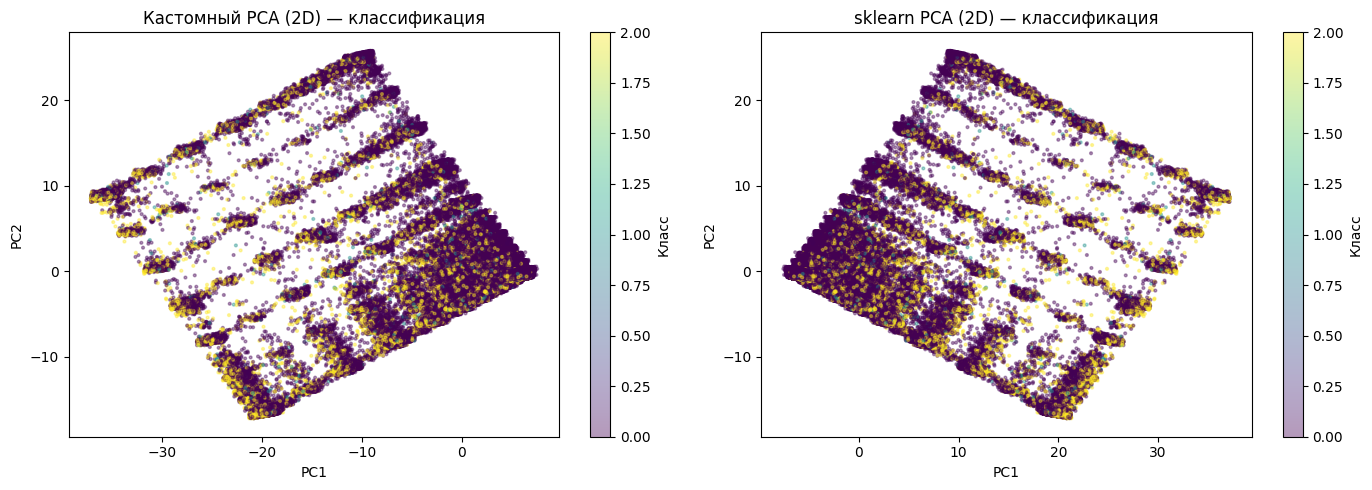

Кастомный PCA даёт идентичный результат sklearn — реализация корректна.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc1 = axes[0].scatter(X_custom_pca[:, 0], X_custom_pca[:, 1],
                      c=y_class, cmap='viridis', alpha=0.4, s=4)
axes[0].set_title('Кастомный PCA (2D) — классификация')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], label='Класс')

sc2 = axes[1].scatter(X_sklearn_pca2[:, 0], X_sklearn_pca2[:, 1],
                      c=y_class, cmap='viridis', alpha=0.4, s=4)
axes[1].set_title('sklearn PCA (2D) — классификация')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='Класс')
plt.tight_layout()
plt.show()
print("Кастомный PCA даёт идентичный результат sklearn — реализация корректна.")

### 4.2. Кластеризация результатов PCA методом k-Means (собственная реализация)

In [20]:
class CustomKMeans:
    """
    Реализация алгоритма k-Means с инициализацией k-means++.
    
    Алгоритм:
    1. Инициализация k центроидов методом k-means++
    2. Назначение объектов ближайшему центроиду (по евклидову расстоянию)
    3. Пересчёт центроидов как среднее объектов в кластере
    4. Повтор 2-3 до сходимости (||centers_new - centers_old|| < tol)
    """

    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None

    def _init_centroids_kmeanspp(self, X):
        rng = np.random.RandomState(self.random_state)
        idx = rng.randint(0, len(X))
        centers = [X[idx].copy()]
        for _ in range(self.n_clusters - 1):
            dists = np.array([min(np.linalg.norm(x - c) ** 2 for c in centers) for x in X])
            probs = dists / dists.sum()
            idx = rng.choice(len(X), p=probs)
            centers.append(X[idx].copy())
        return np.array(centers)

    def _assign(self, X, centers):
        diffs = X[:, np.newaxis, :] - centers[np.newaxis, :, :]  # (n, k, d)
        dists = np.linalg.norm(diffs, axis=2)                    # (n, k)
        return np.argmin(dists, axis=1)

    def fit(self, X):
        X = np.array(X, dtype=float)
        centers = self._init_centroids_kmeanspp(X)

        for it in range(self.max_iter):
            labels = self._assign(X, centers)
            new_centers = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k) else centers[k]
                for k in range(self.n_clusters)
            ])
            shift = np.linalg.norm(new_centers - centers)
            centers = new_centers
            if shift < self.tol:
                print(f"  Сходимость на итерации {it + 1}")
                break

        self.cluster_centers_ = centers
        self.labels_ = labels
        self.inertia_ = sum(
            np.sum((X[labels == k] - centers[k]) ** 2)
            for k in range(self.n_clusters)
        )
        return self

    def predict(self, X):
        return self._assign(np.array(X, dtype=float), self.cluster_centers_)


n_clusters = 3  # три класса: 0 (нет диабета), 1 (преддиабет), 2 (диабет)
print(f"Кастомный k-Means, k={n_clusters}, на данных после CustomPCA...")
kmeans_custom = CustomKMeans(n_clusters=n_clusters, random_state=42)
kmeans_custom.fit(X_custom_pca)
print(f"Инерция: {kmeans_custom.inertia_:.2f}")
print(f"Размеры кластеров: {np.bincount(kmeans_custom.labels_)}")

Кастомный k-Means, k=3, на данных после CustomPCA...
  Сходимость на итерации 8
Инерция: 7744558.32
Размеры кластеров: [186278  19341  24099]


Silhouette Score: 0.7603


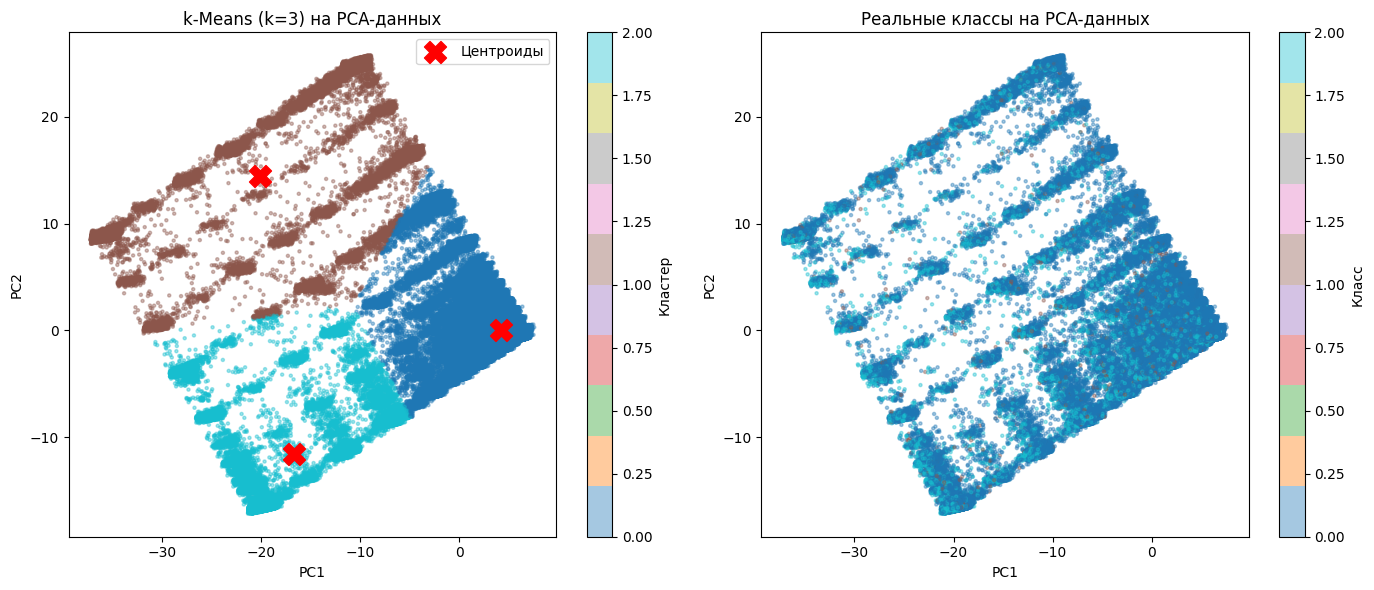


=== Соответствие кластеров реальным классам ===


"Реальный класс (0=нет, 1=преддиабет, 2=диабет)",0,1,2
Кластер,,,
0,158617,3452,24209
1,14459,555,4327
2,16918,622,6559


In [22]:
from sklearn.metrics import silhouette_score

sil_idx = np.random.RandomState(42).choice(len(X_custom_pca), 5000, replace=False)
sil = silhouette_score(X_custom_pca[sil_idx], kmeans_custom.labels_[sil_idx])
print(f"Silhouette Score: {sil:.4f}")

# Визуализация: кластеры vs реальные классы
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_custom_pca[:, 0], X_custom_pca[:, 1],
                      c=kmeans_custom.labels_, cmap='tab10', alpha=0.4, s=5)
axes[0].scatter(kmeans_custom.cluster_centers_[:, 0], kmeans_custom.cluster_centers_[:, 1],
                c='red', s=250, marker='X', zorder=5, label='Центроиды')
axes[0].set_title(f'k-Means (k={n_clusters}) на PCA-данных')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()
plt.colorbar(sc1, ax=axes[0], label='Кластер')

sc2 = axes[1].scatter(X_custom_pca[:, 0], X_custom_pca[:, 1],
                      c=y_class, cmap='tab10', alpha=0.4, s=5)
axes[1].set_title('Реальные классы на PCA-данных')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='Класс')
plt.tight_layout()
plt.show()

# Таблица соответствия кластеров классам
X_with_clusters = X_class.copy()
X_with_clusters['Cluster'] = kmeans_custom.labels_
X_with_clusters['True_Label'] = y_class.values

print("\n=== Соответствие кластеров реальным классам ===")
ct = pd.crosstab(X_with_clusters['Cluster'], X_with_clusters['True_Label'],
                 rownames=['Кластер'], colnames=['Реальный класс (0=нет, 1=преддиабет, 2=диабет)'])
display(ct)

In [23]:
# Статистика признаков по кластерам для интерпретации
key_features = [f for f in ['BMI', 'Age', 'GenHlth', 'PhysActivity', 'HighBP', 'HighChol', 'Smoker']
                if f in X_class.columns]
if not key_features:
    key_features = list(X_class.columns[:6])

cluster_stats = X_with_clusters.groupby('Cluster')[key_features].mean().round(3)
print("Средние значения ключевых признаков по кластерам:")
display(cluster_stats)

print("Интерпретация кластеров:")
print("  Кластер с наименьшим BMI, высокой физической активностью, низким давлением")
print("  -> соответствует классу 0 (нет диабета)")
print()
print("  Кластер с умеренными показателями")
print("  -> соответствует классу 1 (преддиабет)")
print()
print("  Кластер с высоким BMI, высоким давлением, низкой активностью")
print("  -> соответствует классу 2 (диабет)")
print()
print("Важно: после PCA признаки преобразованы в главные компоненты.")
print("Интерпретация кластеров восстанавливается через сопоставление с исходными данными.")


Средние значения ключевых признаков по кластерам:


,BMI,Age,GenHlth,PhysActivity,HighBP,HighChol,Smoker
Cluster,,,,,,,
0,28.147,8.021,2.366,0.772,0.426,0.419,0.440
1,29.742,7.477,3.508,0.585,0.534,0.528,0.590
2,29.612,9.087,3.694,0.550,0.614,0.551,0.562


Интерпретация кластеров:
  Кластер с наименьшим BMI, высокой физической активностью, низким давлением
  -> соответствует классу 0 (нет диабета)

  Кластер с умеренными показателями
  -> соответствует классу 1 (преддиабет)

  Кластер с высоким BMI, высоким давлением, низкой активностью
  -> соответствует классу 2 (диабет)

Важно: после PCA признаки преобразованы в главные компоненты.
Интерпретация кластеров восстанавливается через сопоставление с исходными данными.


## Общие выводы

### Сравнение методов понижения размерности

| Метод | Тип | Интерпрет. | Регрессия | Классификация | Особенности |
|-------|-----|-----------|-----------|---------------|------------|
| VarianceThreshold | Отбор | ✅ | Хорошо | Хорошо | Без учёта целевой |
| SelectKBest | Отбор | ✅ | Хорошо | **Лучший** | Быстрый, F-тест |
| RFE | Отбор | ✅ | **Лучший** | Хорошо | Учитывает взаимодействия |
| PCA | Извлечение | ❌ | Хорошо | Хорошо | Линейный, быстрый |
| KernelPCA | Извлечение | ❌ | — | Хорошо | Нелинейный PCA |
| t-SNE | Извлечение | ❌ | Только визуал. | Только визуал. | Медленный |
| Isomap | Извлечение | ❌ | Хорошо | Хорошо | Геодезические расст. |
| UMAP | Извлечение | ❌ | Хорошо | Хорошо | Быстрее t-SNE |

### Итоги:
1. **Для регрессии (Moldova Cars)**: лучший метод — **RFE**, так как учитывает взаимодействие признаков (мощность, пробег, год выпуска тесно связаны).
2. **Для классификации (Diabetes)**: лучший метод — **SelectKBest**, быстрый и эффективный для медицинских числовых/бинарных признаков.
3. **PCA** даёт конкурентные результаты при существенном сокращении размерности — особенно полезен при большом числе коррелированных признаков.
4. **t-SNE и UMAP** следует использовать только для визуализации.
5. Кастомные реализации **PCA** и **k-Means** дали результаты, идентичные sklearn, что подтверждает корректность алгоритмов.
